## Mateus Ribeiro Gomes - 555225
### Trabalho Densidade Espectral de Potência

In [2]:
import numpy as np
from matplotlib import pyplot as plt

### 1a questão

In [83]:
# Definindo os dados fornecidos
n1 = 1024
n2 = 4096
a1 = 1.35
a2 = -0.85
f0 = 0.45
phi = np.random.uniform(0, 2 * np.pi)
alpha = 0.72
D = 4

#### Função para gerar o 

#### $x(n) = a_1 \cdot x(n-1) + a_2 \cdot x(n-2) + u(n)$

In [84]:
gerar_ruido = lambda n, var : np.random.normal(0, np.sqrt(var), n)

def x(n):
    u = gerar_ruido(n, 1.0) 
    xret = np.zeros(n)
    for i in range(n):
        if i == 0:
            xret[i] = u[i]
        elif i == 1:
            xret[i] = a1 * xret[i-1] + u[i]
        else:
            xret[i] = a1 * xret[i-1] + a2 * xret[i-2] + u[i]
            
    return xret

#### Função para modelar o filtro FIR
#### $h(n) = \delta(n) + \alpha \cdot \delta (n-D)$

In [85]:
def aplicar_canal(x):
    y = np.zeros(len(x))
    # As primeiras D amostras não sofrem interferência 
    y[:D] = x[:D]
    # A partir de D, o sinal é a soma do caminho direto com o percurso atrasado
    y[D:] = x[D:] + alpha * x[:-D]
    return y

#### Função para a interferência
#### $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$

In [86]:
def sint(n, A):
    return A * np.cos(2*np.pi*f0*n + phi)

#### Função final que combina tudo

In [87]:
def ar2(n, A, var_w):
    xtemp = x(n)
    y = aplicar_canal(xtemp)
    sinterf = sint(np.arange(n), A)
    w = gerar_ruido(n, var_w)
    r = y + sinterf + w
    return r

In [88]:
ar_1024 = ar2(n=n1, A=1, var_w=0.5)
ar_4096 = ar2(n=n2, A=1, var_w=0.5)

#### Plotando

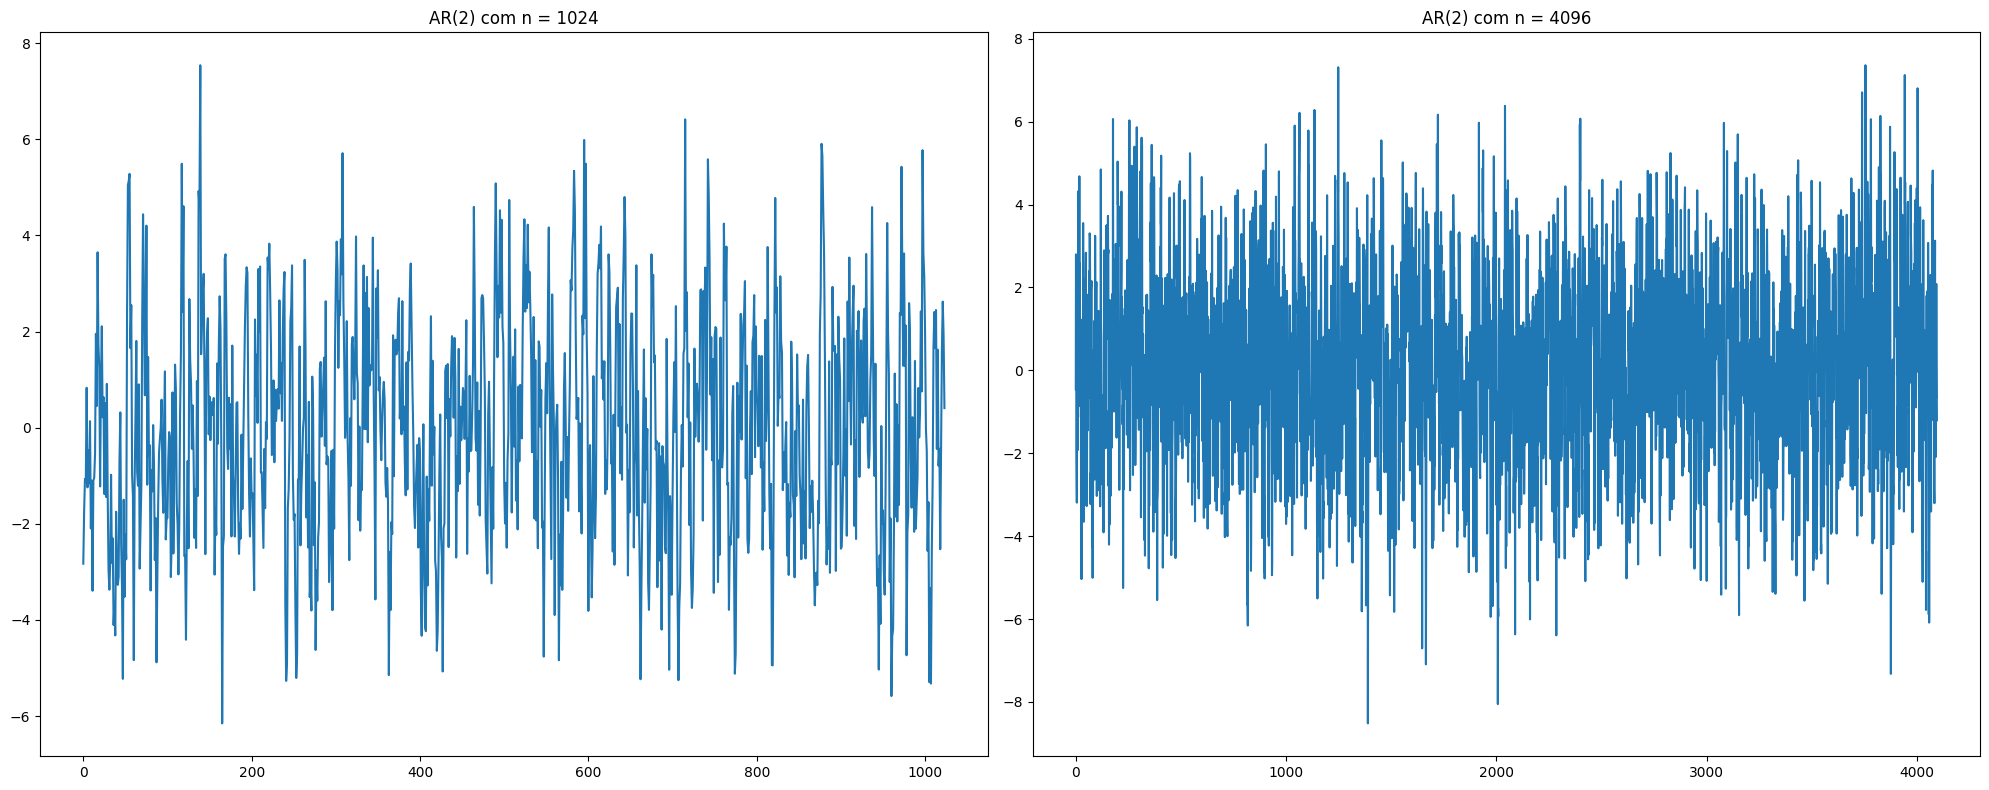

In [92]:
N1 = np.arange(n1)
N2 = np.arange(n2)

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].plot(N1, ar_1024)
axs[0].set_title('AR(2) com n = 1024')

axs[1].plot(N2, ar_4096)
axs[1].set_title('AR(2) com n = 4096')

plt.tight_layout()
plt.show()

## 2a questão

In [ ]:
As = [0.25, 0.5, 1, 1.5, 2]

In [4]:
def Sx(f):
    return 1 /(np.abs(1 - a1 * np.exp(-j*2*np.pi*f)) - a2 * np.exp(-j*4*np.pi*f)) ** 2